# Pauli Propagation

In [1]:
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp, commutator, random_statevector

from math import cos, sin
from functools import partial
from tqdm import tqdm
import numpy as np
from numpy.linalg import matrix_power

from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf, expH
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from pauli import *

fig_dir, data_dir = './figs', './data'
mpl.rcParams['legend.frameon'] = True
set_fontsize(linewidth=2.0)

## Setup: Hamiltonian, Trotter, and initial state

In [ ]:
n = 6
t = 3  # t = n
t_num = 100
r = 50

hx, hy, Jx = 1, 0.9, 0.8
H_model = 'MFI'
if H_model == 'TFI':
    qimf = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
    xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
    xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
    H_list = [xx_even, qimf.y_terms, xx_odd]
    H_ordered = sum(H_list)
else:
    print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
    qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
    xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
    xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
    x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
    H_list = [x_terms, qimf.y_terms, xx_even, xx_odd]
    # H_list = [xx_even, x_terms, qimf.y_terms, xx_odd]
    H_ordered = sum(H_list)
# H_list = qimf.ham_par
# # H_ordered = sum(H_list[1][::-1], H_list[0])
# H_ordered = sum(H_list)
assert H_ordered.equiv(sum(qimf.ham))
num_terms = len(qimf.ham)
print(f'Hamiltonian terms: {num_terms}')

dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_ordered), dt, use_jax=False)
U_dt_appro = pf(H_ordered, dt, 1, 1)
# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1) + SparsePauliOp('I'*(n-3)+'XXZ', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1)
# z1 = SparsePauliOp('I'*(n-2)+'XX', 1) + SparsePauliOp('I'*(n-1)+'X', 1)
commutator(qimf.ham[0], qimf.ham[3]).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j]))

U_dt_ideal_dense = expH(sum(H_ordered), t/t_num, use_jax=False)
ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal_dense, i)@init_state) for i in range(t_num+1)]
trott_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_appro, i)@init_state) for i in range(r+1)]

print('even-odd grouping: ', qimf.ham_par)
print('ob: ', z1)
print(H_ordered.paulis)
# for g in list(qimf.ham.paulis):
# for g in list(sum(qimf.ham_par).paulis):
#     print(g)

QIMF model with hx=1, hy=0.9, Jx=0.8, n=6
Hamiltonian terms: 17
t=3, r=50, dt=0.06
even-odd grouping:  [SparsePauliOp(['IIIIXX', 'IIXXII', 'XXIIII', 'IIIIIX', 'IIIXII', 'IXIIII', 'IIIIIY', 'IIIYII', 'IYIIII'],
              coeffs=[0.8+0.j, 0.8+0.j, 0.8+0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.9+0.j, 0.9+0.j,
 0.9+0.j]), SparsePauliOp(['IIIXXI', 'IXXIII', 'IIIIXI', 'IIXIII', 'XIIIII', 'IIIIYI', 'IIYIII', 'YIIIII'],
              coeffs=[0.8+0.j, 0.8+0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.9+0.j, 0.9+0.j, 0.9+0.j])]
ob:  SparsePauliOp(['IIIIIZ'],
              coeffs=[1.+0.j])
['IIIIIX', 'IIIIXI', 'IIIXII', 'IIXIII', 'IXIIII', 'XIIIII', 'IIIIIY',
 'IIIIYI', 'IIIYII', 'IIYIII', 'IYIIII', 'YIIIII', 'IIIIXX', 'IIXXII',
 'XXIIII', 'IIIXXI', 'IXXIII']


## Evolution

In [25]:
print(cos(dt)**2, sin(dt)**2, dt**2)
## observable evolution
evo_ob, evo_ob_untrunc = [z1], [z1]
w_thres = 4
is_trunc = True

for i in tqdm(range(r)):
    # print('+', end='')
    # for g in list(qimf.ham):
    for g in list(H_ordered):
        # print(g)
        temp = []
        for item in list(evo_ob[-1]):
            # print(item)
            if commutator(g, item).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j])):
                # print(item, g)
                temp.append(item)
            else:
                norm_g = SparsePauliOp(g.paulis, coeffs=[1])  
                angle = 2*dt*g.coeffs[0].real
                branch = math.cos(angle)*item + 1j*math.sin(angle)*norm_g@item
                # branch = pauli_rotation_evo(g, dt, item, coeffs=[c,s])
                # branch = c*item + 1j*s*g@item
                temp.append(branch)
        ob_g = sum(temp).simplify()
        # temp_step.append(ob_g)
        evo_ob.append(ob_g)
        # print(f"#Pauli={len(list(ob_g))}, 2-norm={np.linalg.norm(ob_g, ord='fro')/ np.sqrt(2**n)}")
    evo_ob_untrunc.append(ob_g)
    print(len(evo_ob[-1]))
    # print(len(evo_ob[-1]), evo_ob[-1])
    if is_trunc:
        evo_ob[-1] = truncate_high_weight_pauli(ob_g, w_thres)
# print('evo_ob:', evo_ob)
# np.save(f'{data_dir}/expvals_pauli_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}.npy', evo_ob)

0.9964043179269332 0.0035956820730668735 0.0036


  4%|▍         | 2/50 [00:00<00:02, 18.18it/s]

5
14
58


  8%|▊         | 4/50 [00:00<00:08,  5.44it/s]

114


...

3519


 98%|█████████▊| 49/50 [05:28<00:10, 10.31s/it]

3520


100%|██████████| 50/50 [05:38<00:00,  6.77s/it]

3520


In [333]:
test = evo_ob[-1]
print(len(test), test)
truncate_high_weight_pauli(test, w_thres)

6 SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY'],
              coeffs=[-0.428567+0.j,  0.395459+0.j,  0.144332+0.j,  0.295462+0.j, -0.305682+0.j,
 -0.223025+0.j])


SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY'],
              coeffs=[-0.428567+0.j,  0.395459+0.j,  0.144332+0.j,  0.295462+0.j, -0.305682+0.j,
 -0.223025+0.j])

In [26]:
print(low_weight_pauli(evo_ob[-1], 3))

# expvals, expvals_1, expvals_3, expvals_6 = [], [], [], []
expvals, expvals_low, expvals_w = [], [], []
for item in evo_ob[::num_terms]:
    expvals.append(expect_value(item.to_matrix(), init_state))
    # expvals_1.append(expect_value(low_weight_pauli(item, 1).to_matrix(), init_state))
    temp_w, temp_low = [], []
    for w in range(1, n+1):
        temp_w.append(abs(expect_value(w_weight_pauli(item, w).to_matrix(), init_state)))
        temp_low.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
        # temp.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
    expvals_w.append(temp_w)
    expvals_low.append(temp_low)
expvals_w, expvals_low = np.array(expvals_w), np.array(expvals_low)

data_distribution = []
# exp_vals = []
for item in evo_ob[::num_terms]:
    weight_norm_dict = pauli_weight_norm(item)
    # print(len(list(item)), weight_norm_dict)
    data_distribution.append(weight_norm_dict)

norm_weight_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    for w in range(1, n+1):
        if w in item:
            temp_step.append(item[w])
        else:
            temp_step.append(0)
    norm_weight_steps.append(temp_step)
print('norm_weight_steps:', norm_weight_steps)

# print('diff 2-norm: ', [2**(-n/2)*np.linalg.norm(ob.to_matrix() - evo_ob[::num_terms][i].to_matrix(), ord='fro')/complete_norm for i, ob in enumerate(evo_ob_untrunc)])
expvals_low_part = [expect_value(item.to_matrix(), init_state) for item in evo_ob_untrunc]
print('without truncation (at last rotation of one Trotter):\n', expvals_low_part)
print('with truncation:\n', expvals_low[:, w_thres-1])
print(np.abs(expvals_low_part - expvals_low[:, w_thres-1]))

SparsePauliOp(['IIIIIZ', 'IIIIXY', 'IIIIIX', 'IIIIIY', 'IIIIXZ', 'IIIIZY', 'IIIXYY', 'IIIIZZ', 'IIIXYZ', 'IIIIXX', 'IIIIZX', 'IIIXYX', 'IIIIYI', 'IIIXZI', 'IIIIYY', 'IIIXZY', 'IIIIYZ', 'IIIXZZ', 'IIIIYX', 'IIIXZX', 'IIIIZI', 'IIIXYI', 'IIIZYY', 'IIIZZY', 'IIIXXY', 'IIIXIZ', 'IIIZXY', 'IIIYIY', 'IIXZIY', 'IIIZIZ', 'IIIYXZ', 'IIXYIZ', 'IIIZYZ', 'IIIZYX', 'IIIZZI', 'IIXYZI', 'IIIZZZ', 'IIIXXZ', 'IIIXIY', 'IIIZXZ', 'IIIYIZ', 'IIXZIZ', 'IIIZIY', 'IIIYXY', 'IIXYIY', 'IIIZZX', 'IIIZYI', 'IIXYYI', 'IIIXXX', 'IIIZXX', 'IIIYIX', 'IIXZIX', 'IIIIXI', 'IIIXXI', 'IIIZXI', 'IIIYII', 'IIXYXI', 'IIXZII', 'IIIYYY', 'IIIYZY', 'IIIYYZ', 'IIIYYX', 'IIIYZI', 'IIXZZI', 'IIIYZZ', 'IIIYZX', 'IIIYYI', 'IIXZYI', 'IIIYXX', 'IIIZIX', 'IIXYIX', 'IIXIZY', 'IIZIZY', 'IIYIYY', 'IIZZIY', 'IIZYIZ', 'IIXIYY', 'IIZIYY', 'IIYIZY', 'IIZYIY', 'IIZZIZ', 'IIXXIZ', 'IIYIXY', 'IIZXIZ', 'IIYIIZ', 'IXZIIZ', 'IIZYZI', 'IIXIZZ', 'IIZIZZ', 'IIYIYZ', 'IIZZZI', 'IIXIZX', 'IIXXZI', 'IIXIYI', 'IIZIZX', 'IIYIYX', 'IIZXZI', 'IIZIYI', 'IXYI

In [28]:
trott_ops = [matrix_power(U_dt_appro, i) for i in range(r+1)]
ideal_ops = [matrix_power(U_dt_ideal, i) for i in range(r+1)]
trott_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in trott_ops]
ideal_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in ideal_ops]
# print(len(trott_obs), len(expvals_low_part))

In [29]:
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')
pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_ob_untrunc)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 100
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in haar_states] for i, ob in enumerate(evo_ob_untrunc)]
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in haar_states] for i, ob in enumerate(ideal_obs)]

[0.0, 4.599890428834346e-16, 9.768938850511043e-16, 1.4795631092382484e-08, 6.164171229488403e-08, 1.5275326877793593e-07, 8.45774783880653e-07, 3.6515619156926963e-06, 1.1853929556051252e-05, 3.1641847604130245e-05, 7.33252948977656e-05, 0.00015243930715388014, 0.00029048984640493985, 0.0005149513665685676, 0.0008582685991162172, 0.0013557594039016818, 0.0020426362465693197, 0.002950762699478439, 0.0041062031892302175, 0.005529018576219221, 0.0072369104872974255, 0.009254192054600112, 0.01162661812641588, 0.01444053066877093, 0.017841220802921012, 0.02204168474482024, 0.027312698391204104, 0.03395158204823222, 0.04223742805782579, 0.05238603086918024, 0.06451472870388376, 0.07862119585815378, 0.09457706526157797, 0.11213706809220625, 0.13096442687282425, 0.15067174615071552, 0.17087373539504794, 0.1912445259838824, 0.21156916148090477, 0.23177722136593507, 0.2519477952503961, 0.2722802254735493, 0.2930341700717674, 0.31445326197262075, 0.33669416426067694, 0.35978237655866285, 0.38360

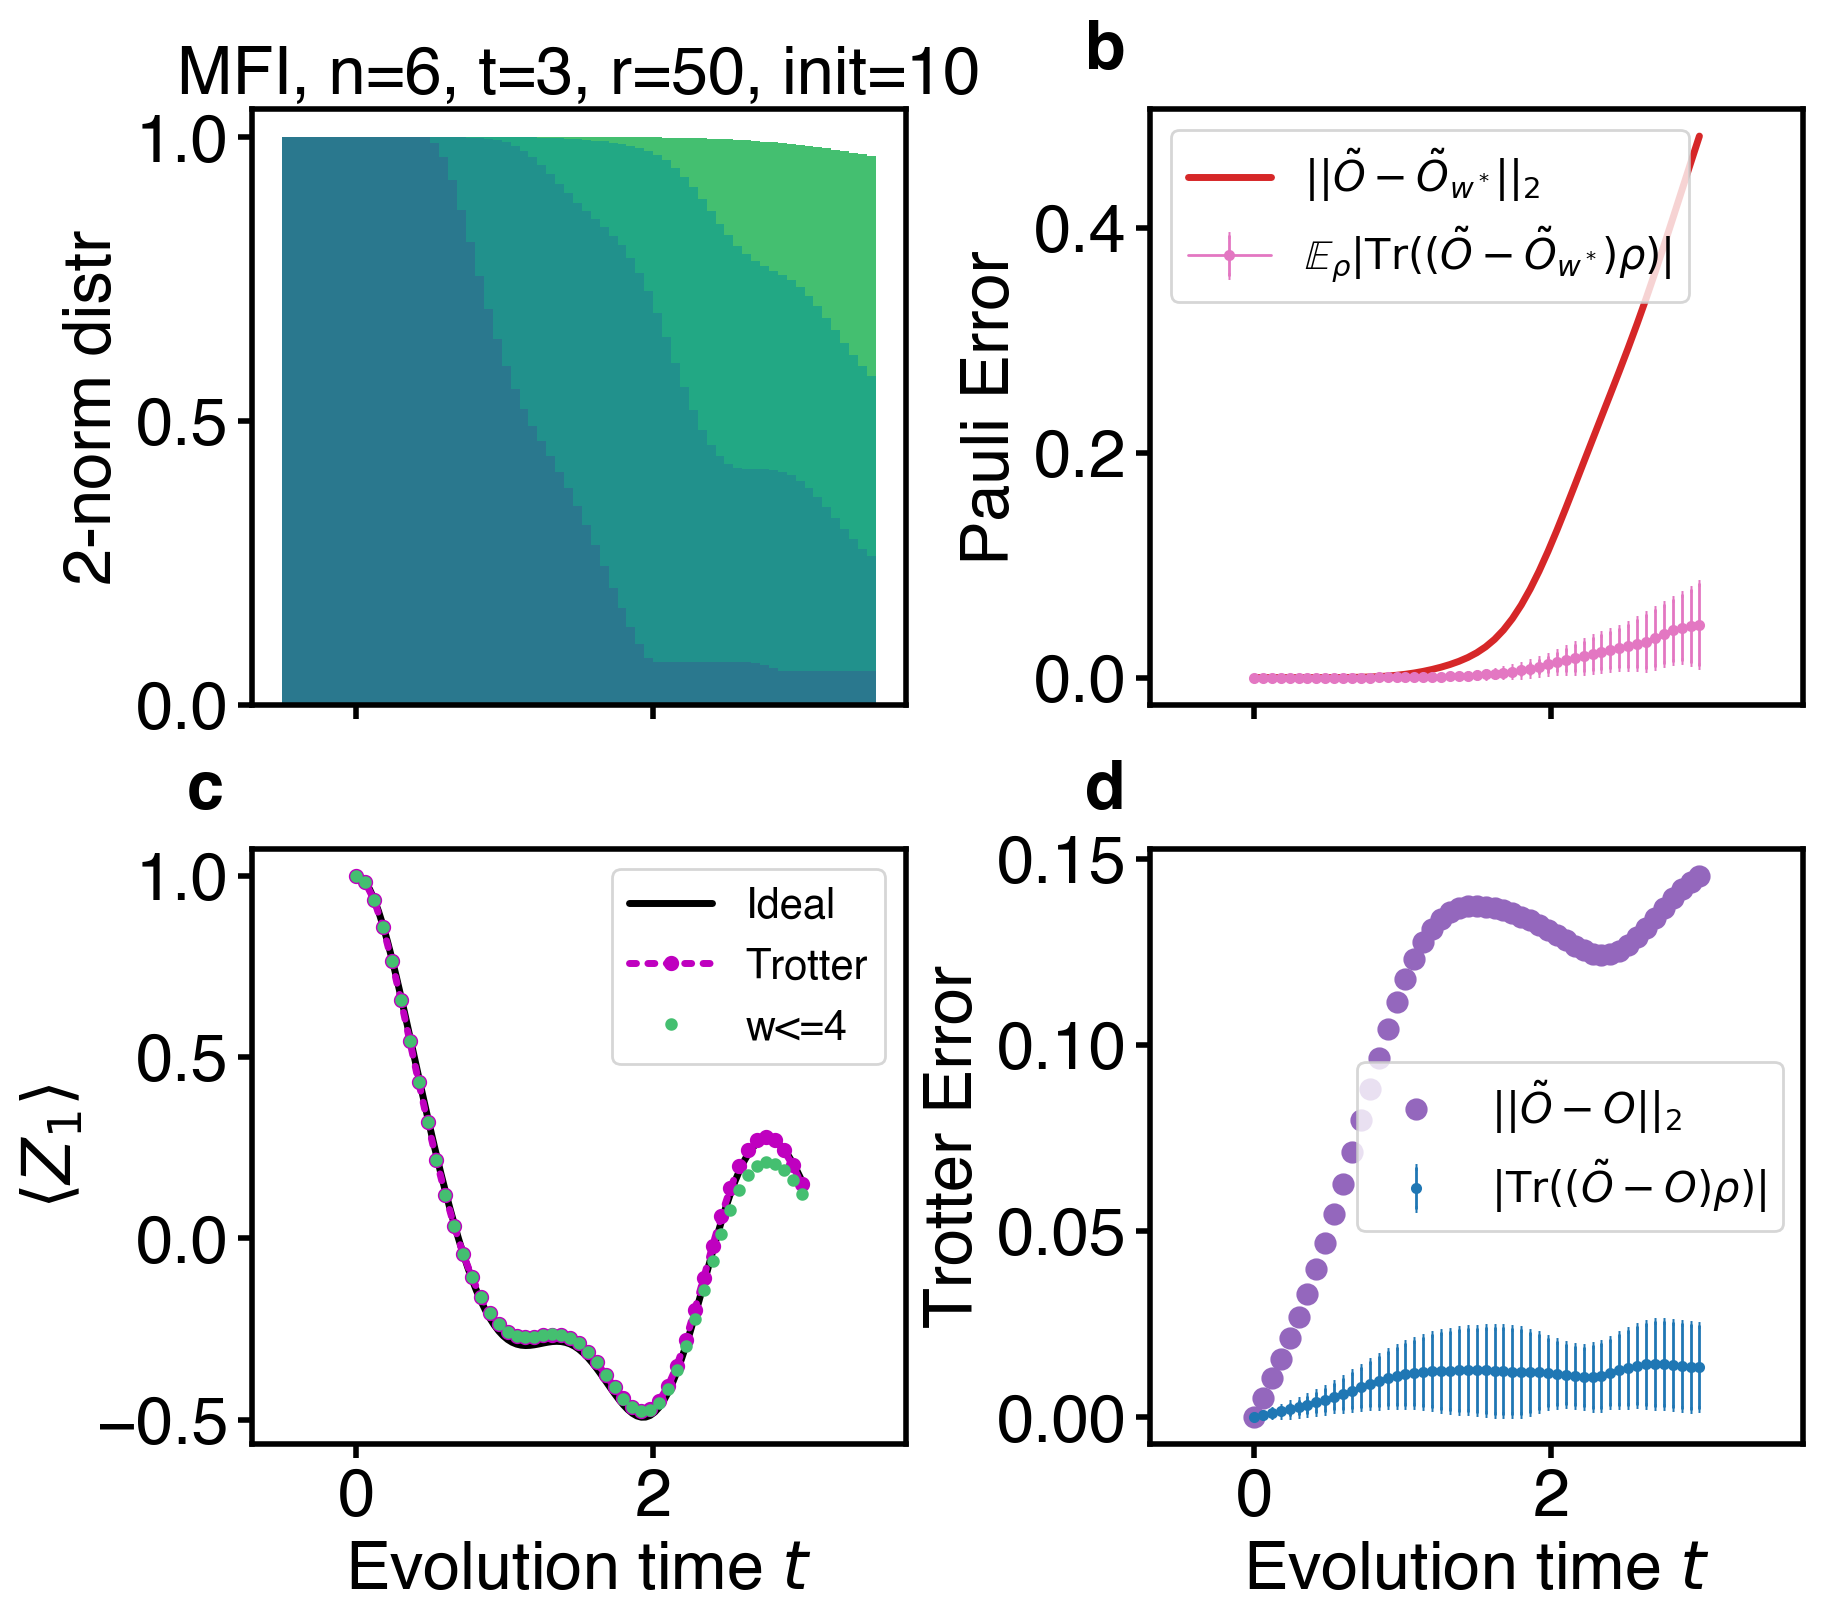

In [30]:
## Low-weight (truncated) Evolution
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained')
axes[1,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[1,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[1,0].plot(t_list, expvals_low[:, w_thres-1], '.', label=rf'w<={w_thres}', color=colors[w_thres-1], ms=4)
# axes[1,0].plot(t_list, expvals_low_part, '.', label=rf'w<~{w_thres}', markersize=2)
axes[1,0].set_xlabel(rf'Evolution time $t$'); axes[1,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[1,0].legend(loc='upper right', fontsize='small')

axes[0,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[0,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{ w^*})\rho)|$', c='tab:pink', capsize=0.5, lw=1, ms=3)
axes[0,1].set_ylabel(rf'Pauli Error'); axes[0,1].legend(loc='upper left', fontsize='small')
# axes[0,1].set_yscale('log')
# axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[1,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:purple')
axes[1,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[1,1].set_ylabel(rf'Trotter Error')
axes[1,1].set_xlabel(rf'Evolution time $t$'); axes[1,1].legend(loc='center right', fontsize='small')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(expvals_w))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[0,0].bar(t_list, norm2_distr, 1, color=colors[w-1], label=f'w<={w}')

axes[0,0].set_ylabel('2-norm distr') # axes[0,1].legend(loc='upper right')
axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

for ax, label in zip(axes.flatten(), ['', 'b', 'c', 'd']): ## add label a, b, c, d to each subfigure
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/expvals_pauli_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_lc.pdf', bbox_inches='tight')

## Ideal Evolution

w>=8, 0.6344139550161207
w>=7, 0.6344139550161207
w>=6, 0.6344139550161207
w>=5, 0.6344139550161207
w>=4, 0.8768669036423988
w>=3, 0.9395104812480366
w>=2, 0.9684329564028321


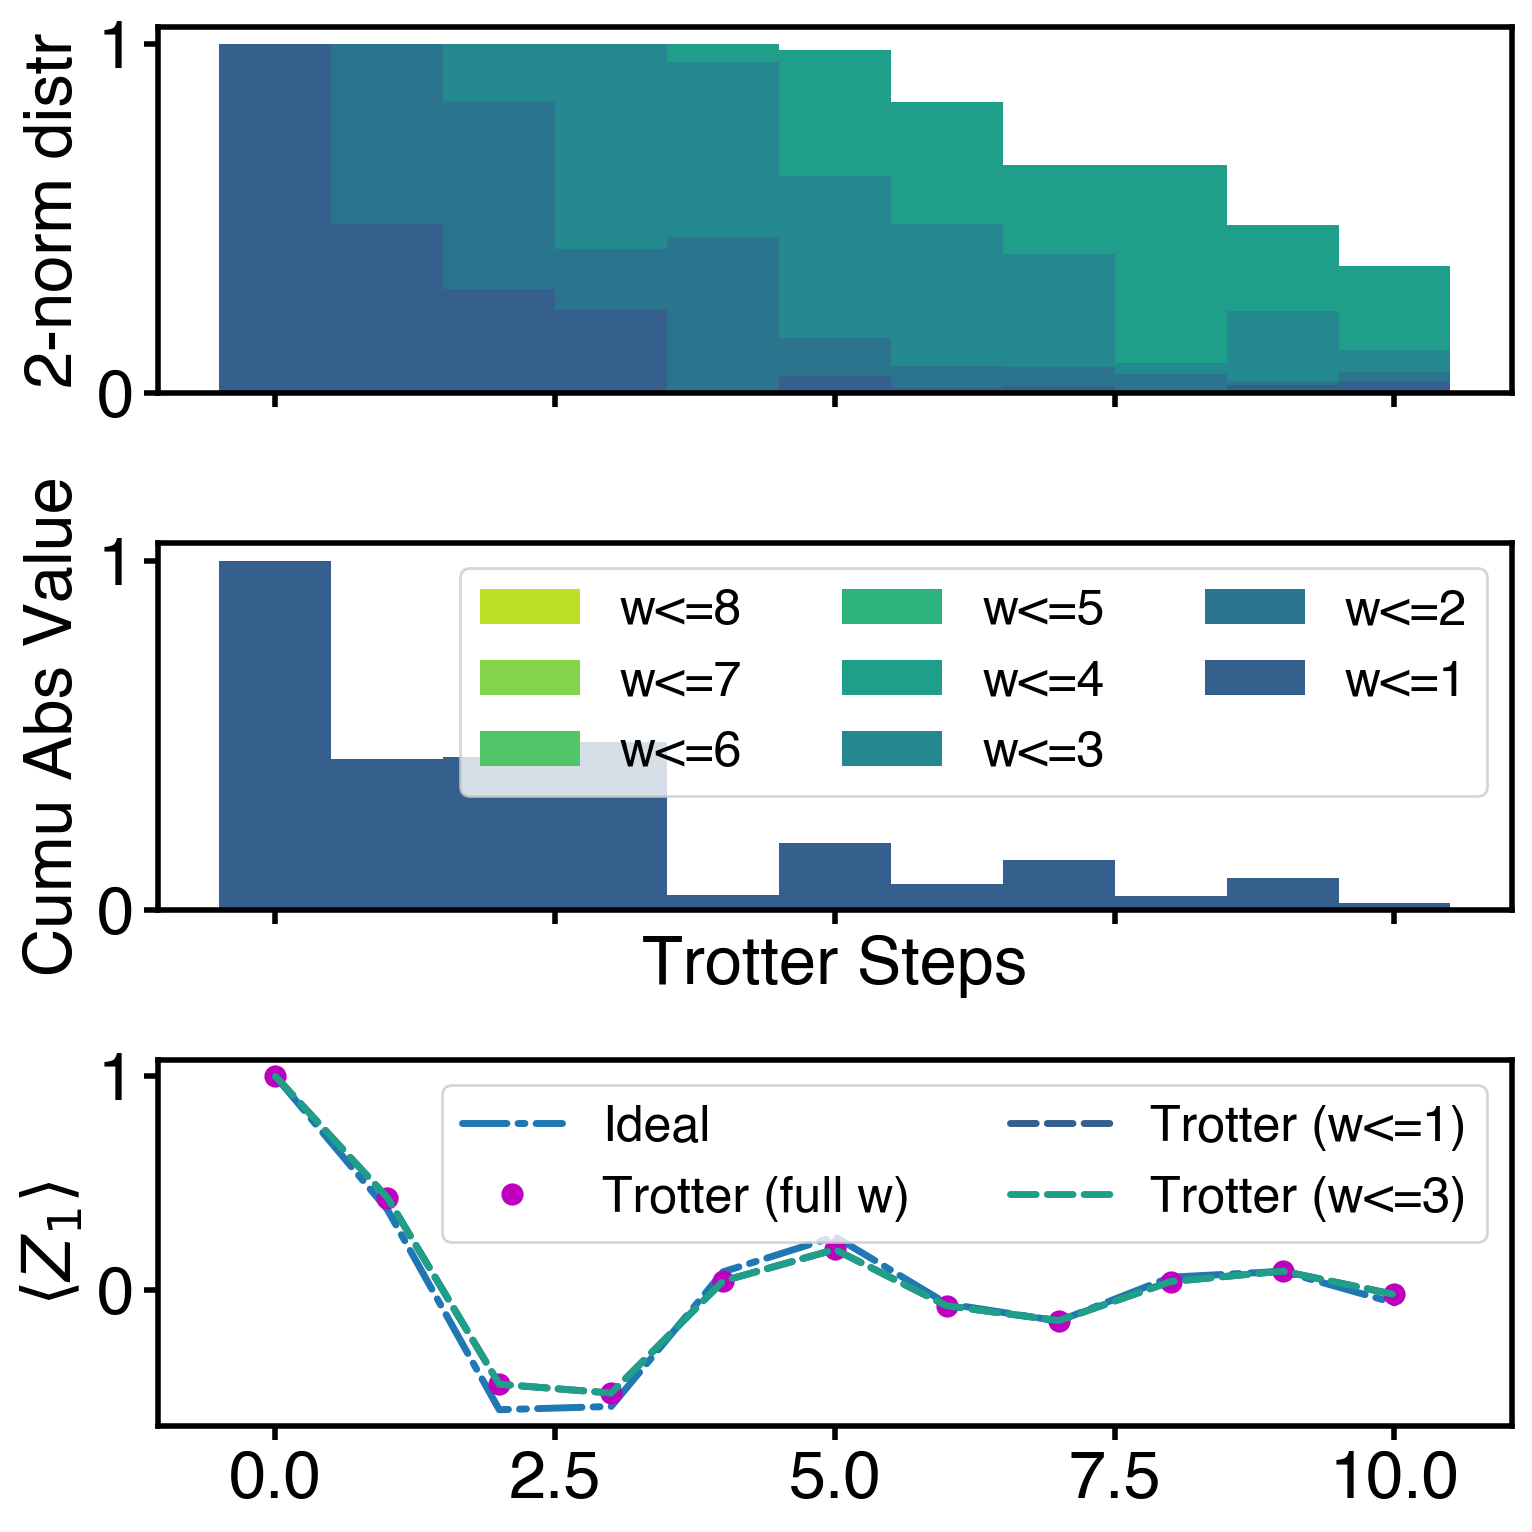

In [ ]:
t_list = list(range(len(expvals)))

# Use wider spacing between bars for better visibility
x_pos = np.arange(len(expvals_w)) 
bar_width = 1.0
k = n
# colors = plt.cm.viridis(np.linspace(0.9, 0.1, k))
# colors = plt.cm.viridis(np.linspace(0.0, 1, k))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, k))

fig, [ax3, ax2, ax] = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
ax.plot(range(len(ideal_expvals)), ideal_expvals, '-.', label='Ideal')
ax.plot(t_list, expvals, '.', label='Trotter (full w)', c='m')
ax.plot(t_list, expvals_low[:, 0], '--', label='Trotter (w<=1)', color=colors[0])
ax.plot(t_list, expvals_low[:, 1], '--', label='Trotter (w<=3)', color=colors[3])
# ax.plot(t_list, expvals_low[:, 5], '--', label='Trotter (w<=5)', color=colors[5])
# ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'$\langle Z_1 \rangle$')
ax.legend(loc='upper right', ncol=2, fontsize='medium')

# Plot with different alpha values for better layering effect
for w in range(n, 0, -1):
    cumulative_values = [sum(expvals_w[i][:w]) for i in range(len(expvals_w))]
    # Vary alpha based on w value
    # alpha = 0.6 + (w / n) * 0.4
    alpha = 1
    bars = ax2.bar(x_pos, cumulative_values, bar_width, color=colors[w-1], alpha=alpha, label=f'w<={w}')
# for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(expvals_w))]

    if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = ax3.bar(x_pos, norm2_distr, bar_width, color=colors[w-1], label=f'w<={w}')
# print(x_pos)
# ax2.set_xlabel('Trotter Steps')
ax2.set_ylabel('Cumu Abs Value')
# ax2.set_title('Cumulative Values with Enhanced Visibility')
ax2.legend(loc='upper right', ncol=3, fontsize='medium')  # make legend horizontal

ax2.set_xlabel('Trotter Steps')
ax3.set_ylabel('2-norm distr') # ax3.legend(loc='upper right')
ax3.set_xlabel(rf'Evolution time $t$')

# fig.savefig(f'{fig_dir}/expvals_pauli_t={t}_{t_num}.pdf', bbox_inches='tight')
fig.savefig(f'{fig_dir}/expvals_pauli_t={t}_{t_num}_{init_state_str}.pdf', bbox_inches='tight')

In [86]:
from math import cos, sin
t = 0.05
c2_IZ, c2_XY, c2_XX = cos(2*t), cos(2*t)*sin(2*t), sin(2*t)**2
print(c2_IZ, c2_XY, c2_XX)
print(c2_IZ**2 + c2_XY**2 + c2_XX**2)

c, s = cos(t), sin(t)
c1_IZ, c1_XY, c1_XX = c**2-c*s**2, c**2*s+c**3*s-s**3, 2*c*s**2+c**2*s**2
print(c1_IZ, c1_XY, c1_XX)
print(c1_IZ**2 + c1_XY**2 + c1_XX**2)

0.9950041652780258 0.09933466539753062 0.009966711079379185
1.0
0.995007287024282 0.09952150211255016 0.007481268999306777
1.0000000000000002


In [ ]:
test = evo_ob[8]
print(test)
print(sum([coeff**2 for coeff in test.coeffs]))
c, s = math.cos(dt*2), math.sin(dt*2)
pauli_weight_norm(test)

SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY'],
              coeffs=[ 0.829367+0.j, -0.40063 +0.j,  0.389418+0.j])
(1+0j)


{1: 0.8483533546735826, 2: 0.1516466453264173}

## Legacy

In [ ]:

cumulative_norm_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    # print(item)
    for w in range(1, n+1):
        temp_sum = 0
        for k in range(w, n+1):
            if k in item:
                # print('k', k, item[k])
                temp_sum += item[k]
        # print('sum',temp_sum)
        temp_step.append(temp_sum)
        # print(item, temp_step)
    cumulative_norm_steps.append(temp_step)
print('cumulative_norm_steps:', cumulative_norm_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_norm_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(cumulative_norm_steps[0])):
    ax.plot(range(len(cumulative_norm_steps)), np.array(cumulative_norm_steps)[:,w], label=f'w>={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Cumulative norm')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/cumulative_norm_steps.pdf', bbox_inches='tight')

norm_weight_steps: [[1.0, 1.0, 0, 0, 0, 0, 0, 0], [1.0000209489808225, 0.9999790510191775, 0, 0, 0, 0, 0, 0], [1.0001814226773924, 0.9996317403690785, 0.00018683695352863014, 0, 0, 0, 0, 0], [1.0006887226214014, 0.9985808327541053, 0.0007304338649076543, 1.0759792488277703e-08, 0, 0, 0, 0], [1.0017816765338718, 0.9962494154484095, 0.0019688141872421703, 9.383051283962442e-08, 4.3505756510723055e-13, 0, 0, 0], [1.0036580972809943, 0.99207228453723, 0.004269126621030906, 4.915545006337152e-07, 6.7408702845783305e-12, 0, 0, 0], [1.006396964232906, 0.9855885595642544, 0.008012596116044953, 1.8800297335878313e-06, 5.7748814222423213e-11, 1.847907130033839e-16, 0, 0], [1.0098888042257421, 0.9765441718396173, 0.013561231337695438, 5.7922551123929354e-06, 3.426426038059433e-10, 3.7441992831475595e-15, 0, 0], [1.0137861273197215, 0.9649665739930966, 0.02123206714655115, 1.5229972456092651e-05, 1.5690453679054512e-09, 3.870156791508872e-14, 0, 0], [1.0174831425781299, 0.951199300579965, 0.031282

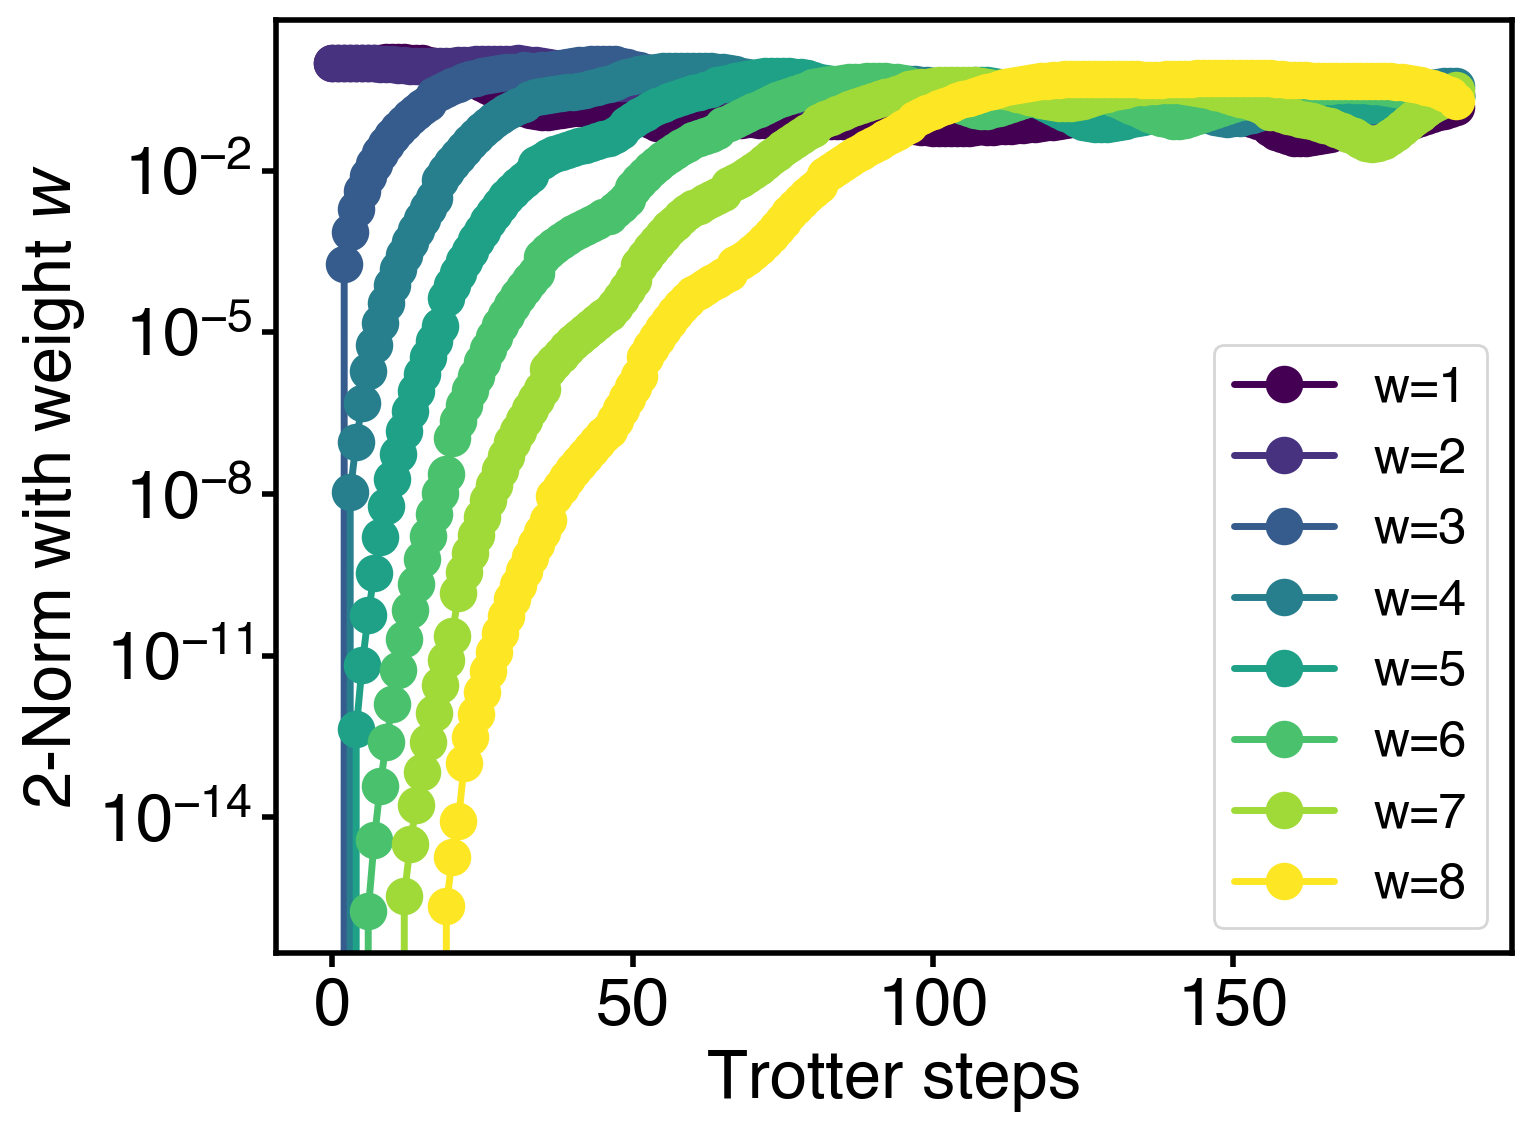

In [ ]:

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(norm_weight_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(norm_weight_steps[0])):
    ax.plot(range(len(norm_weight_steps)), np.array(norm_weight_steps)[:, w], label=f'w={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'2-Norm with weight $w$')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/norm_weight_steps.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'Pauli weight distribution')

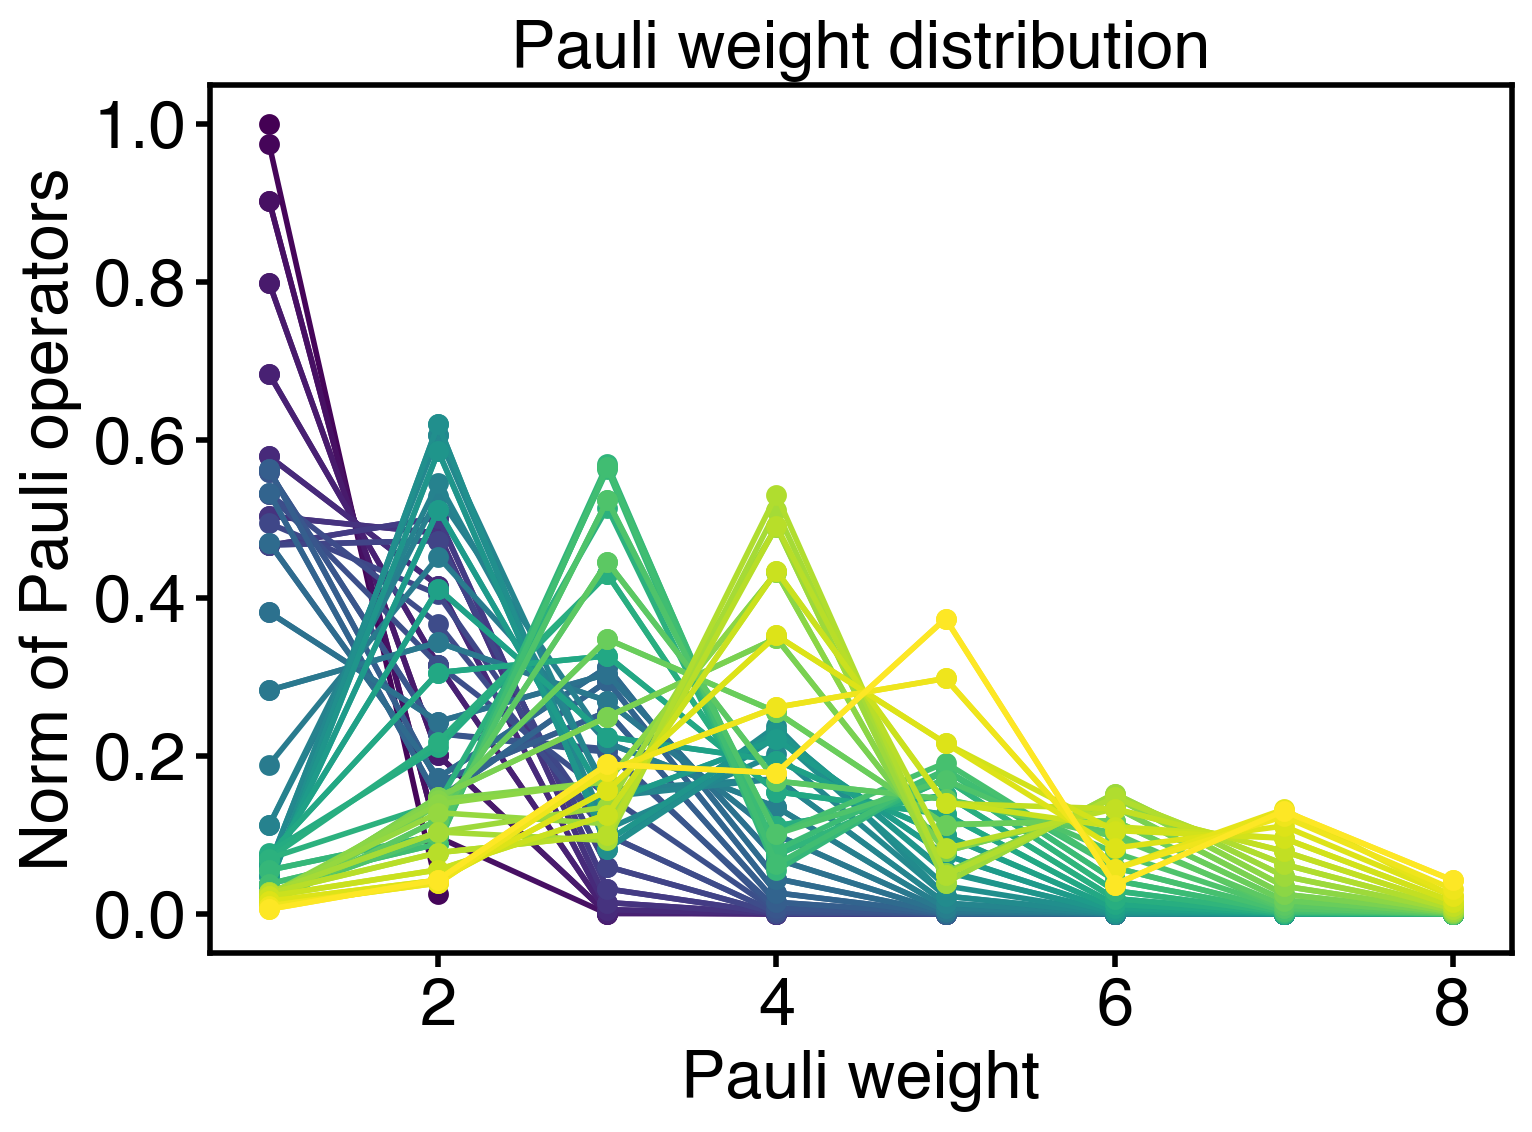

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
# use gradient color for each line
colors = plt.cm.viridis(np.linspace(0, 1, len(data_distribution)))
ax.set_prop_cycle(color=colors)
for i, item in enumerate(data_distribution):
    x = list(item.keys())
    y = [item[k] for k in x]
    ax.plot(x, y, label=f't={i*n}', marker='o', markersize=5, linewidth=2)
ax.set_xlabel('Pauli weight')
ax.set_ylabel('Norm of Pauli operators')
ax.set_title('Pauli weight distribution')